# Proceso de Machine Learning

### Carga de datos y eliminar variables innecesarias

In [113]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from pickle import dump
from sklearn.cluster import KMeans



# Leer el archivo CSV
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv', sep=',') # Este archivo CSV contiene comas como separadores

df = df[["MedInc", "Latitude", "Longitude"]]
df.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


[Text(0.5, 1.0, 'Mapa de ingresos (MedInc)'),
 Text(0.5, 0, 'Longitud'),
 Text(0, 0.5, 'Latitude')]

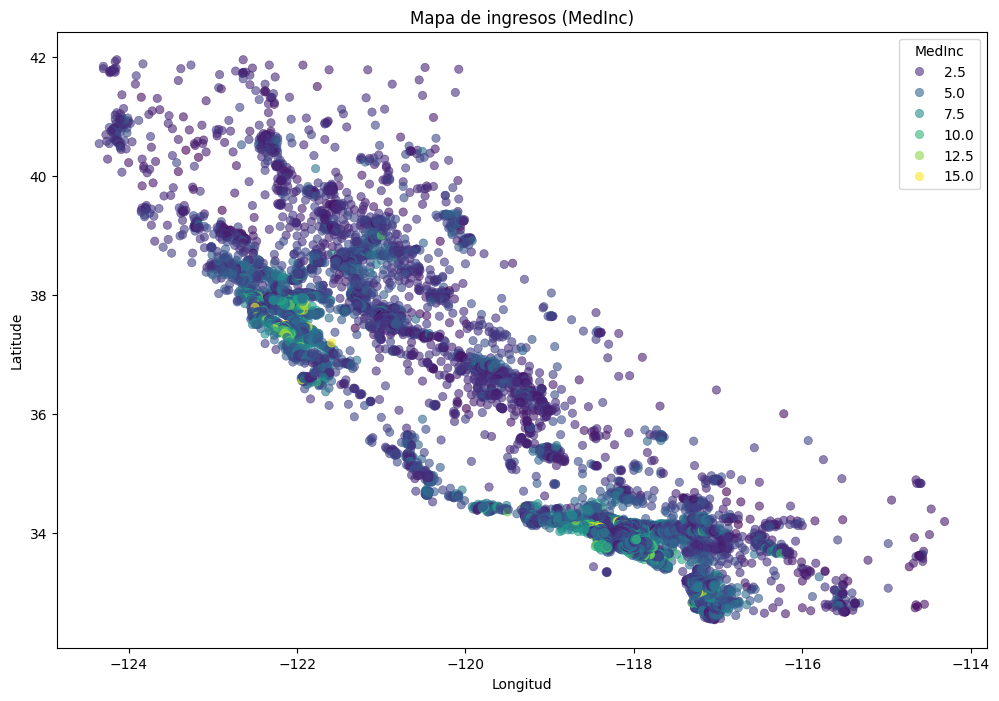

In [114]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data = df, x = "Longitude", y = "Latitude", hue = "MedInc", palette="viridis", alpha=0.6, edgecolor=None).set(title="Mapa de ingresos (MedInc)", xlabel = "Longitud", ylabel = "Latitude")

In [115]:
X_train, X_test = train_test_split(df, test_size = 0.2, random_state = 10)

X_train.head()

,MedInc,Latitude,Longitude
12346,2.5212,33.82,-116.52
19326,2.6316,38.50,-122.94
16824,5.1550,37.63,-122.49
6869,2.8229,34.06,-118.11
16677,1.9653,35.13,-120.66


In [116]:
model_km = KMeans(n_clusters = 6, n_init = "auto", random_state = 10)
model_km.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",10
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## Añadir cluster al conjunto de datos

In [117]:
y_train = list(model_km.labels_)
X_train["cluster"] = y_train
X_train.head()

,MedInc,Latitude,Longitude,cluster
12346,2.5212,33.82,-116.52,5
19326,2.6316,38.50,-122.94,0
16824,5.1550,37.63,-122.49,2
6869,2.8229,34.06,-118.11,5
16677,1.9653,35.13,-120.66,1


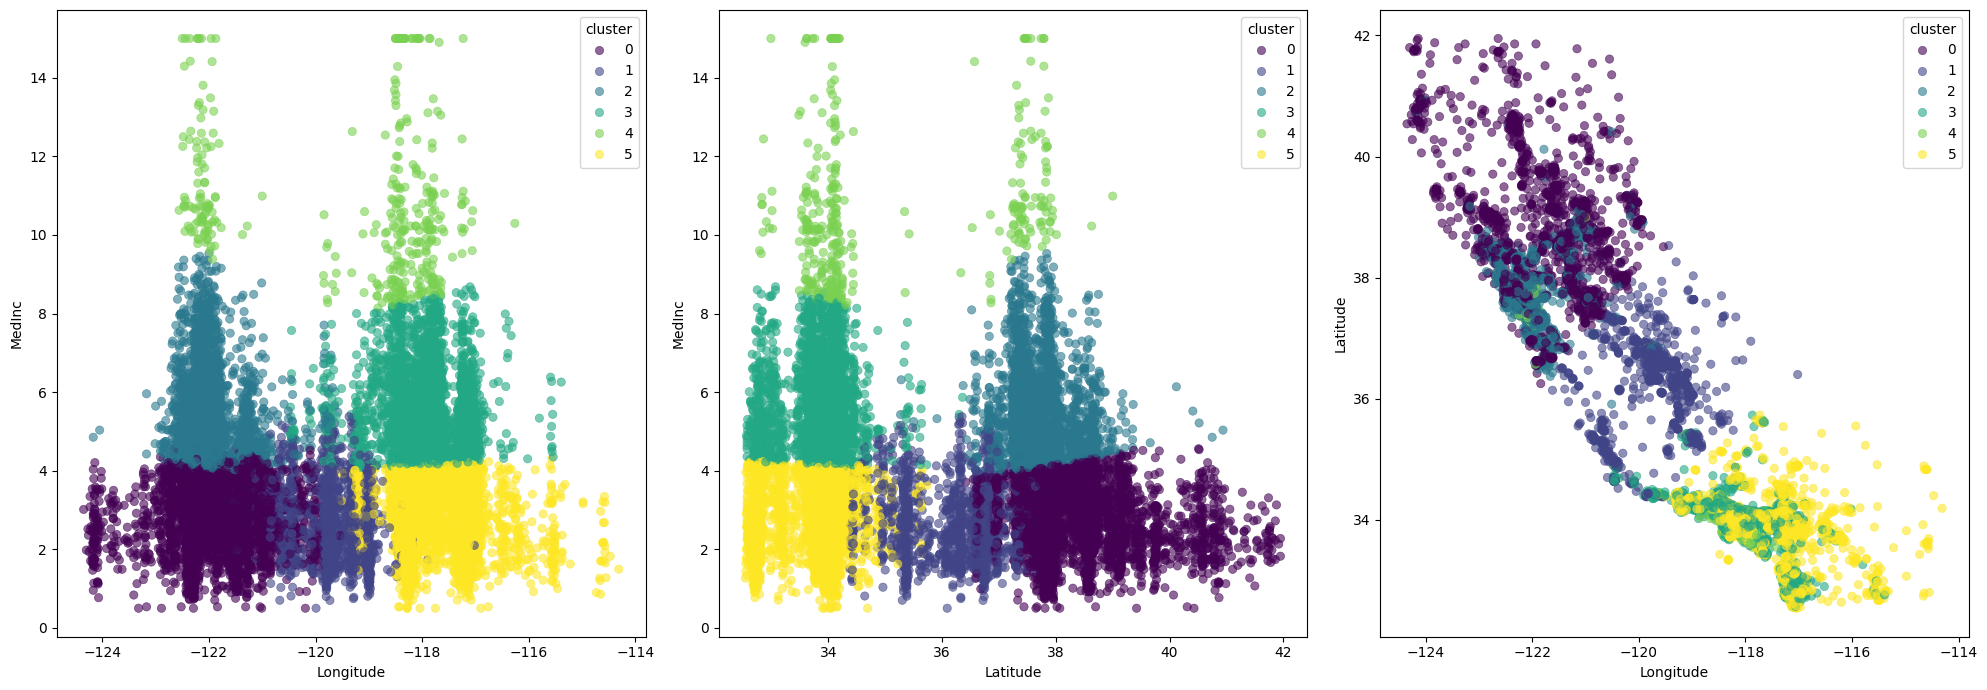

In [118]:
fig, axis = plt.subplots(1, 3, figsize = (20, 7))

# Crear un diagrama de dispersión múltiple

sns.scatterplot(ax = axis[0], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette="viridis", alpha=0.6, edgecolor=None)
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette="viridis", alpha=0.6, edgecolor=None)
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "Latitude", hue = "cluster", palette="viridis", alpha=0.6, edgecolor=None)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()


Los clusters geográficamente hablando están separados de maneras coherente representando aproximadamente el mapa de California por lo que la longitud y la latitud son factores relevantes en la segmentación.   
MedInc nos aporta cierta información pero no es lo suficientemente definitoria para separar los clusters por si solo
y al ser gráficos 2D no se pueden apreciar correctamente los clusters por lo que puede haber solapamientos.  
Requerirá de múltiples variables para su correcta separación.

## Predecir el conjunto de test

In [119]:
y_test = list(model_km.predict(X_test))
X_test["cluster"] = y_test
X_test.head()

,MedInc,Latitude,Longitude,cluster
20303,5.2783,34.16,-119.18,3
16966,3.9722,37.55,-122.31,0
10623,4.5094,33.67,-117.77,3
6146,3.1034,34.11,-117.95,5
2208,4.6726,36.81,-119.87,1


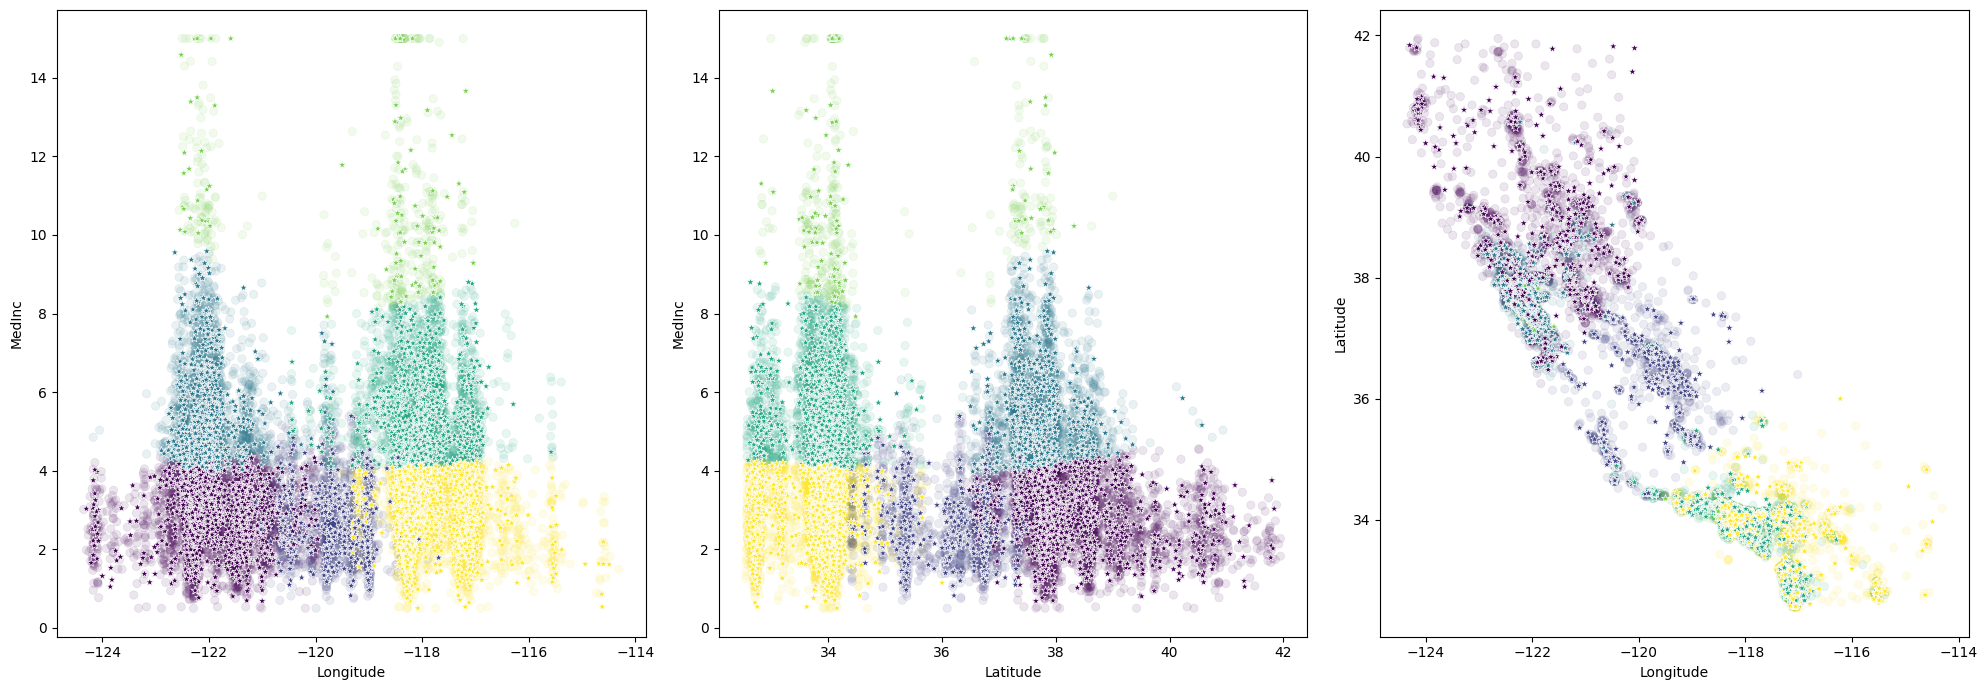

In [120]:
fig, axis = plt.subplots(1, 3, figsize = (20, 7))

# Crear un diagrama de dispersión múltiple

sns.scatterplot(ax = axis[0], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette="viridis", alpha=0.1, edgecolor=None)
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette="viridis", alpha=0.1, edgecolor=None)
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "Latitude", hue = "cluster", palette="viridis", alpha=0.1, edgecolor=None)

sns.scatterplot(ax = axis[0], data = X_test, x = "Longitude", y = "MedInc", hue = "cluster", palette="viridis", marker="*")
sns.scatterplot(ax = axis[1], data = X_test, x = "Latitude", y = "MedInc", hue = "cluster", palette="viridis", marker="*")
sns.scatterplot(ax = axis[2], data = X_test, x = "Longitude", y = "Latitude", hue = "cluster", palette="viridis", marker="*")

# Ajustar el layout
plt.tight_layout()

for ax in axis:
    ax.legend([],[], frameon=False)
    
# Mostrar el plot
plt.show()

Guiándonos por las gráficas, podemos decir que los resultados son satisfactorios ya que tiene una gran fiabilidad.

## Modelo supervisado con K-Means

Para este caso, he elegido un Random Forest para utilizar el K-Means porque capta no linealidades y es un modelo robusto, además de no tener que escalar los datos.

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

params = {
    "n_estimators": [200, 400],
    "criterion": ["gini", "entropy"],
    "max_depth": [1, 3, 5]
}

## Grid seach

In [122]:
grid = GridSearchCV(RandomForestClassifier(random_state=10), params, scoring="accuracy", n_jobs = -1, verbose = 1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("El mejor estimador es: ", best_model)
print("La mejor puntuación es: ", grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


El mejor estimador es:  RandomForestClassifier(max_depth=5, n_estimators=200, random_state=10)
La mejor puntuación es:  1.0


# Métricas finales

In [123]:
model_f = RandomForestClassifier(max_depth=5, n_estimators=200, random_state=10)
model_f.fit(X_train, y_train)

y_pred = model_f.predict(X_train)
metric_train = accuracy_score(y_train, y_pred)


y_pred = model_f.predict(X_test)
metric_test = accuracy_score(y_test, y_pred)


print(f"La mejor métrica de nuestros datasets x_train son: {metric_train} y los x_test son: {metric_test}")

#Guardado de modelo

dump(model_km, open("../models/modelo_K_Means_LatLongMedInc.sav", "wb"))
dump(model_f, open("../models/modelo_entrenado_Random_Forest_con_K_Means_LatLongMedInc.sav", "wb"))

La mejor métrica de nuestros datasets x_train son: 1.0 y los x_test son: 1.0


Vemos que este caso tanto train como test tienen unas métricas de 1.0 en accuracy probablemente porque esta intentando predecir algo que fue creado por las directamente desde las columnas.

In [127]:
importances = pd.Series(model_f.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))

cluster      0.579401
Latitude     0.179930
MedInc       0.158019
Longitude    0.082650
dtype: float64


El código anterior muestra que hay un data leakage ya que "clusters" esta incluida en el X_train y X_test por lo cual, al ser también la variable objetivo que utilizan tanto y_train como y_test, le  
estamos dando la respuesta en cada predicción.